## Making Borders for Images (Padding)

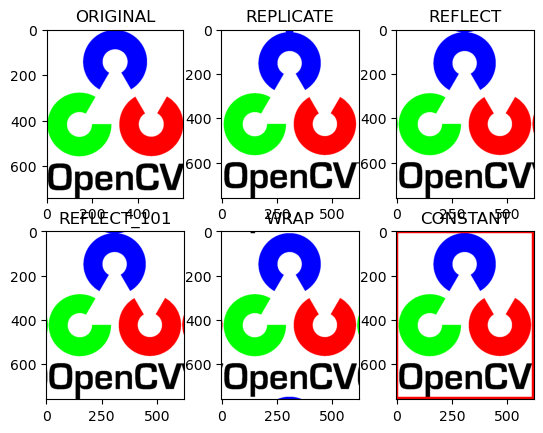

In [15]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

BLUE = [255,0,0]
img1 = cv2.imread('open_cv.png')
replicate = cv2.copyMakeBorder(img1,10,10,10,10,cv2.BORDER_REPLICATE)
reflect = cv2.copyMakeBorder(img1,10,10,10,10,cv2.BORDER_REFLECT)
reflect101 = cv2.copyMakeBorder(img1,10,10,10,10,cv2.BORDER_REFLECT_101)
wrap = cv2.copyMakeBorder(img1,10,10,10,10,cv2.BORDER_WRAP)
constant= cv2.copyMakeBorder(img1,10,10,10,10,cv2.BORDER_CONSTANT,value=BLUE)
plt.subplot(231),plt.imshow(img1,'gray'),plt.title('ORIGINAL')
plt.subplot(232),plt.imshow(replicate,'gray'),plt.title('REPLICATE')
plt.subplot(233),plt.imshow(reflect,'gray'),plt.title('REFLECT')
plt.subplot(234),plt.imshow(reflect101,'gray'),plt.title('REFLECT_101')
plt.subplot(235),plt.imshow(wrap,'gray'),plt.title('WRAP')
plt.subplot(236),plt.imshow(constant,'gray'),plt.title('CONSTANT')
plt.show()


In [16]:
x = np.uint8([250])
y = np.uint8([10])
print (cv2.add(x,y))

print (x+y)

[[260.]
 [  0.]
 [  0.]
 [  0.]]
[4]


### Image Blending

In [17]:
img1 = cv2.imread('py.png')
img2 = cv2.imread('oc.png')
dst = cv2.addWeighted(img1,0.7,img2,0.3,0)
cv2.imshow('dst',dst)
cv2.waitKey(0)
cv2.destroyAllWindows()

### Bitwise Operations

In [18]:
# Load two images
img1 = cv2.imread('images.jpg')
img2 = cv2.imread('opencv.jpg')
# I want to put logo on top-left corner, So I create a ROI
rows,cols,channels = img2.shape
roi = img1[0:rows, 0:cols ]
# Now create a mask of logo and create its inverse mask also
img2gray = cv2.cvtColor(img2,cv2.COLOR_BGR2GRAY)
ret, mask = cv2.threshold(img2gray, 10, 255, cv2.THRESH_BINARY)
mask_inv = cv2.bitwise_not(mask)
# Now black-out the area of logo in ROI
img1_bg = cv2.bitwise_and(roi,roi,mask = mask_inv)
# Take only region of logo from logo image.
img2_fg = cv2.bitwise_and(img2,img2,mask = mask)
# Put logo in ROI and modify the main image
dst = cv2.add(img1_bg,img2_fg)
img1[0:rows, 0:cols ] = dst
cv2.imshow('res',img1)
cv2.waitKey(0)
cv2.destroyAllWindows()

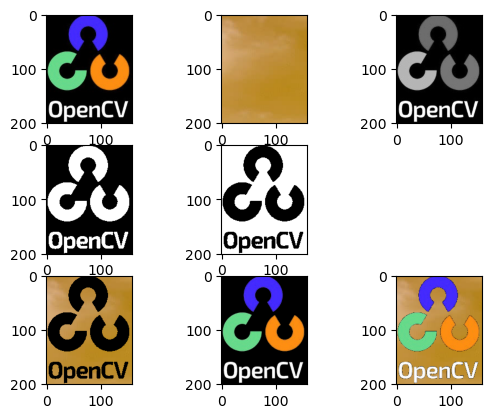

In [19]:
# Load two images
img1 = cv2.imread('images.jpg') # 배경 이미지
img2 = cv2.imread('opencv.jpg') # 들어갈 이미지
x = 20

# I want to put logo on top-left corner, So I create a ROI
rows,cols,channels = img2.shape
roi = img1[0:rows, 0:cols ]
# Now create a mask of logo and create its inverse mask also
img2gray = cv2.cvtColor(img2,cv2.COLOR_BGR2GRAY)

plt.subplot(331),plt.imshow(img2)
plt.subplot(332),plt.imshow(roi)
plt.subplot(333),plt.imshow(img2gray,'gray')

ret, mask = cv2.threshold(img2gray, x, 255, cv2.THRESH_BINARY)
mask_inv = cv2.bitwise_not(mask)

plt.subplot(334),plt.imshow(mask,'gray')
plt.subplot(335),plt.imshow(mask_inv,'gray')

img1_bg = cv2.bitwise_and(roi,roi,mask = mask_inv) # 뒤에 배경
img2_fg = cv2.bitwise_and(img2,img2,mask = mask)
dst = cv2.add(img1_bg,img2_fg)

plt.subplot(337),plt.imshow(img1_bg,'gray')
plt.subplot(338),plt.imshow(img2_fg)
plt.subplot(339),plt.imshow(dst)

plt.show()